Part A — Data preparation

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.Load both datasets and document:
number of rows/columns
missing values / duplicates

In [98]:
sentiment = pd.read_csv('./data/fear_greed_index.csv')
trades =pd.read_csv('./data/historical_data.csv')

In [99]:
# number of rows/columns
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)


Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [100]:
#check duplicates and null values
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

print(sentiment.isnull().sum())
print(trades.isnull().sum())

0
0
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [101]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [102]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [103]:
#Data cleaning
sentiment['classification'] = sentiment['classification'].replace({
    'Extreme Fear':'Fear',
    'Extreme Greed':'Greed'
})

In [104]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Fear,2018-02-04
4,1517808600,11,Fear,2018-02-05


In [105]:
trades.columns = trades.columns.str.lower().str.replace(' ','_')

2.Convert timestamps and align the datasets by date (daily level is fine).

In [106]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [107]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'],format= '%d-%m-%Y %H:%M')
trades['date']=trades['timestamp_ist'].dt.floor('D')

In [108]:
trades['side'] = trades['side'].replace({'BUY':'LONG','SELL':'SHORT'})
trades.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,LONG,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,LONG,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,LONG,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,LONG,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,LONG,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [109]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Fear,2018-02-04
4,1517808600,11,Fear,2018-02-05


In [110]:
#merging datasets
merged=pd.merge(trades,sentiment[['date','classification']],on = 'date',how = 'inner')

In [111]:
merged['classification'].value_counts()

classification
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64

3.Create the key metrics you will analyze, for example:

In [112]:
# daily PnL per trader (or per account)
daily_pnl = merged.groupby('date')['closed_pnl'].sum()
daily_pnl

date
2023-05-01         0.000000
2023-12-05         0.000000
2023-12-14      -205.434737
2023-12-15       -24.632034
2023-12-16         0.000000
                  ...      
2025-04-27      2702.067468
2025-04-28     36906.813759
2025-04-29    125749.613427
2025-04-30     14003.797269
2025-05-01     54536.829297
Name: closed_pnl, Length: 479, dtype: float64

In [113]:
# win rate
merged['win'] = merged['closed_pnl']>0
win_rate = merged['win'].mean()
win_rate

np.float64(0.41124809438589516)

In [114]:
# average trade size
merged['size_usd'].mean()

np.float64(5639.191610563495)

In [115]:
# leverage distribution
q1 = merged['size_usd'].quantile(0.33)
q2 = merged['size_usd'].quantile(0.66)

def leverage_group(x):
    if x <= q1:
        return 'Low'
    elif x <= q2:
        return 'Medium'
    else:
        return 'High'

merged['leverage_type'] = merged['size_usd'].apply(leverage_group)

pd.crosstab(merged['classification'], merged['leverage_type'])

leverage_type,High,Low,Medium
classification,,,
Fear,31017,23336,28884
Greed,28872,33274,28149
Neutral,11925,13098,12663


In [116]:
# number of trades per day
trades_per_day =merged.groupby('date').size()
trades_per_day

date
2023-05-01       3
2023-12-05       9
2023-12-14      11
2023-12-15       2
2023-12-16       3
              ... 
2025-04-27     337
2025-04-28    1379
2025-04-29    2243
2025-04-30    1113
2025-05-01    1230
Length: 479, dtype: int64

In [117]:
# long/short ratio
pd.crosstab(merged['classification'], merged['side'])

side,LONG,SHORT
classification,,
Fear,41205,42032
Greed,42516,47779
Neutral,18969,18717


Part B — Analysis

1.Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [118]:
#Average PnL by sentiment
pnl_analysis = merged.groupby('classification')['closed_pnl'].mean()
#win rate by sentiment
win_rate_by_sentiment = merged.groupby('classification') ['win'].mean()
#Drawdown proxy 
drawdown =merged.groupby('classification')['closed_pnl'].min()
print(pnl_analysis)
print(win_rate_by_sentiment)
print(drawdown)

classification
Fear       49.212077
Greed      53.882281
Neutral    34.307718
Name: closed_pnl, dtype: float64
classification
Fear       0.407871
Greed      0.420311
Neutral    0.396991
Name: win, dtype: float64
classification
Fear       -35681.74723
Greed     -117990.10410
Neutral    -24500.00000
Name: closed_pnl, dtype: float64


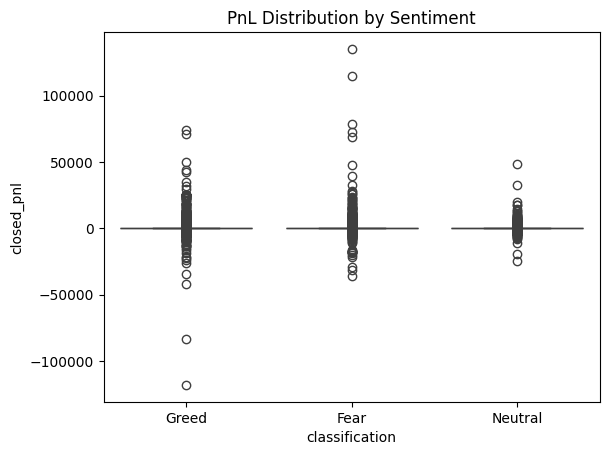

In [119]:
sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.title("PnL Distribution by Sentiment")
plt.savefig("outputs/pnl_boxplot.png")  
plt.show()

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

In [120]:
# trade frequency 
trade_freq = merged.groupby('classification').size()
print(trade_freq)

classification
Fear       83237
Greed      90295
Neutral    37686
dtype: int64


In [121]:
# trade size(leverage)
size_by_sentiment = merged.groupby('classification')['size_usd'].mean()
print(size_by_sentiment)

classification
Fear       7182.011019
Greed      4574.424490
Neutral    4782.732661
Name: size_usd, dtype: float64


In [122]:
# long/short bias
long_short = pd.crosstab(merged['classification'], merged['side'])
print(long_short)

side             LONG  SHORT
classification              
Fear            41205  42032
Greed           42516  47779
Neutral         18969  18717


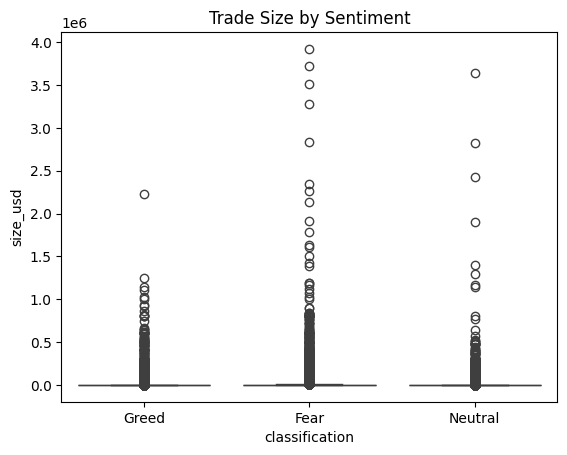

In [123]:
# Trade Size
sns.boxplot(x='classification', y='size_usd', data=merged)
plt.title("Trade Size by Sentiment")
plt.savefig("outputs/trade_size_boxplot.png")
plt.show()

3.Identify 2–3 segments (examples):

In [124]:
# high leverage vs low leverage traders
median = merged['size_usd'].median()
merged['size_group'] = merged['size_usd'].apply(lambda x: 'High' if x>median else 'Low')

In [125]:
# frequent vs infrequent traders
counts = merged['account'].value_counts()
merged['trader_type'] = merged['account'].apply(lambda x: 'Frequent' if counts[x]>50 else 'Infrequent')

In [126]:
# consistent winners vs inconsistent traders
profit = merged.groupby('account')['closed_pnl'].sum()
merged['profit_type'] = merged['account'].apply(lambda x: 'Winner' if profit[x]>0 else 'Loser')

4.Provide at least 3 insights backed by charts/tables.

### 1. Performance vs Sentiment (PnL)

From the PnL boxplot:
- Fear periods show higher volatility with extreme profits and losses
- Greed periods are relatively more stable

Conclusion:
Performance differs across sentiment, with Fear leading to higher risk and drawdowns.

---

### 2. Behavior Change Based on Sentiment

Trade Frequency:
- Greed → 90,295 (highest)
- Fear → 83,237
- Neutral → 37,686

Insight:
Traders are more active during Greed periods.

---

Trade Size (Risk Level):
- Fear → 7182 USD (highest)
- Greed → 4574 USD
- Neutral → 4782 USD

Insight:
Traders take larger risks during Fear periods.

---

Long/Short Bias:
- Greed shows slightly more short trades

Insight:
Traders hedge or take profits even during bullish markets.

---

### 3. Trader Segments

High vs Low Risk Traders:
- Based on trade size (size_usd)
- High-risk traders take larger positions during Fear

Frequent vs Infrequent Traders:
- Frequent traders dominate during Greed periods

Consistent vs Inconsistent Traders:
- Fear shows more extreme outcomes → inconsistent performance

---

### 4. Key Insights (Final)

1. Trading activity is highest during Greed periods.
2. Traders take higher risks during Fear periods.
3. Fear markets show higher volatility and extreme PnL outcomes.

Part C — Actionable output

### Strategy 1: Risk Control During Fear Markets

Observation:
- Traders take larger position sizes during Fear periods
- PnL shows higher volatility and larger drawdowns

Rule:
During Fear markets, traders should reduce position size and avoid aggressive trading.

Actionable Steps:
- Reduce trade size by 30–50%
- Use strict stop-loss
- Avoid overtrading or revenge trading

Conclusion:
Fear-driven markets increase risk exposure, so capital preservation should be the priority.

---

### Strategy 2: Controlled Participation During Greed Markets

Observation:
- Trading activity is highest during Greed periods
- Traders show slight short bias (profit booking / hedging)

Rule:
During Greed markets, traders can increase participation but should use disciplined strategies.

Actionable Steps:
- Increase trade frequency cautiously
- Use partial profit booking
- Apply trailing stop-loss
- Consider hedge positions near market peaks

Conclusion:
Greed markets provide opportunities, but controlled execution is required to avoid reversals.